<a href="https://colab.research.google.com/github/Rehanabbaxi/Facial-Emotion-Recognition/blob/main/FER_Colab_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎭 Facial Emotion Recognition — Experimentation & Benchmarking Notebook

A **self-contained, research-grade** Colab notebook for FER. It is intentionally
*not* a production stack (no FastAPI/Docker/MLflow) — it is a place to **iterate,
benchmark architectures, and understand trade-offs**.

**Framework: PyTorch.** Chosen for consistency with the companion production
project and because the dynamic API makes custom training loops, focal loss, and
mixed-precision experimentation easy to read and modify.

---

### Dataset choice — FER2013, and when to switch

We use **FER2013** (35,887 images, 48×48 grayscale, 7 emotions). It is the
standard FER benchmark: free, no manual approval, and small enough to train many
configs on a free T4.

**Known limitations** that *cap* achievable accuracy (state-of-the-art on the
raw labels is only ~73–76%):
- **Label noise** — a non-trivial fraction of images are mislabeled or ambiguous.
- **Low resolution** (48×48) and grayscale discard fine facial detail.
- **Imbalance** — `disgust` has ~10× fewer samples than `happy`.

**Better alternatives** (and why we still start with FER2013):
| Dataset | Why it's better | Cost |
|---|---|---|
| **FER+** | Re-annotated FER2013 (10 labelers/image) → much cleaner labels. **Drop-in:** same images, just swap the label CSV. | Free |
| **RAF-DB** | Real-world, higher-res, crowd-validated labels (~15–20 pts more headroom). | Free, requires request |
| **AffectNet** | ~400k images, valence/arousal + categories. Best ceiling. | Large (~120GB), license request |

> **Recommendation:** prototype here on FER2013, then for a real accuracy jump,
> apply the **FER+ relabeling** to these same images (lightest-effort upgrade) or
> move to **RAF-DB**. A switch hook is provided in the data section.

## 0 · Environment setup

Runs as-is on a **Colab free-tier T4 GPU**. Set `Runtime → Change runtime type →
T4 GPU` first. No manual path edits are required anywhere in this notebook.

In [ ]:
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=False)

# Almost everything is preinstalled on Colab. We only add what may be missing.
try:
    import kagglehub  # modern, auth-light Kaggle dataset downloader
except Exception:
    pip_install(['kagglehub'])

# Optional: MTCNN face detector for the webcam demo (Haar cascade is the default
# and needs no install). Uncomment to use MTCNN instead:
# pip_install(['facenet-pytorch'])

print('Setup cell complete.')

Setup cell complete.


In [ ]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

# ---- Global knobs (edit these, not paths) ----
QUICK_RUN  = False   # True -> fewer epochs for a fast end-to-end smoke test
NUM_EPOCHS = 8 if QUICK_RUN else 40
BATCH_SIZE = 128
IMG_SIZE_CNN = 48    # native FER2013 resolution for the custom CNN
IMG_SIZE_TL  = 96    # upscaled input for the transfer-learning model
print('NUM_EPOCHS =', NUM_EPOCHS, '| QUICK_RUN =', QUICK_RUN)

PyTorch 2.11.0+cu128 | device: cuda
GPU: Tesla T4
NUM_EPOCHS = 40 | QUICK_RUN = False


## 1 · Download FER2013

**Primary:** `kagglehub` pulls `msambare/fer2013` (already organized into
`train/` and `test/` folders, one subfolder per emotion → perfect for
`ImageFolder`).

**Fallback options** if Kaggle is unavailable (printed by the cell):
1. Upload your own `kaggle.json` token (Account → Create New API Token) — the cell
   detects it and uses the Kaggle CLI.
2. Manually upload a FER2013 zip to `/content/data/` and re-run.

**To switch to FER+ / RAF-DB later:** point `train_dir` / `test_dir` at a folder
laid out the same way (`<split>/<emotion>/<image>`); everything downstream is
dataset-agnostic.

In [ ]:
DATA_ROOT = '/content/data'
os.makedirs(DATA_ROOT, exist_ok=True)

def find_fer_dirs(root):
    '''Return (train_dir, test_dir) for the first folder containing both.'''
    for base, dirs, _ in os.walk(root):
        names = {d.lower() for d in dirs}
        if 'train' in names and 'test' in names:
            tr = os.path.join(base, [d for d in dirs if d.lower()=='train'][0])
            te = os.path.join(base, [d for d in dirs if d.lower()=='test'][0])
            # sanity: train should hold class subfolders
            if any(os.path.isdir(os.path.join(tr, c)) for c in os.listdir(tr)):
                return tr, te
    return None, None

train_dir, test_dir = find_fer_dirs(DATA_ROOT)

if train_dir is None:
    got = False
    # Attempt 1: kagglehub (no token needed for many public datasets)
    try:
        import kagglehub
        path = kagglehub.dataset_download('msambare/fer2013')
        print('kagglehub downloaded to:', path)
        train_dir, test_dir = find_fer_dirs(path)
        got = train_dir is not None
    except Exception as e:
        print('[kagglehub failed]', e)

    # Attempt 2: Kaggle CLI with an uploaded kaggle.json
    if not got:
        try:
            if not os.path.exists('/root/.kaggle/kaggle.json'):
                print('Upload your kaggle.json (Kaggle > Account > Create New API Token):')
                from google.colab import files
                up = files.upload()
                os.makedirs('/root/.kaggle', exist_ok=True)
                fn = list(up.keys())[0]
                os.replace(fn, '/root/.kaggle/kaggle.json')
                os.chmod('/root/.kaggle/kaggle.json', 0o600)
            subprocess.run(['kaggle', 'datasets', 'download', '-d', 'msambare/fer2013',
                            '-p', DATA_ROOT, '--unzip'], check=True)
            train_dir, test_dir = find_fer_dirs(DATA_ROOT)
            got = train_dir is not None
        except Exception as e:
            print('[kaggle CLI failed]', e)

    if not got:
        raise RuntimeError(
            'Automatic download failed. Manual fallback:\n'
            '  1) Download FER2013 (msambare/fer2013) from kaggle.com\n'
            '  2) In Colab, upload/extract it under /content/data so you have\n'
            '     /content/data/.../train/<emotion>/ and .../test/<emotion>/\n'
            '  3) Re-run this cell.')

assert train_dir and test_dir, 'train/test dirs not resolved'
print('train_dir =', train_dir)
print('test_dir  =', test_dir)
print('classes   =', sorted(os.listdir(train_dir)))

Using Colab cache for faster access to the 'fer2013' dataset.
kagglehub downloaded to: /kaggle/input/fer2013
train_dir = /kaggle/input/fer2013/train
test_dir  = /kaggle/input/fer2013/test
classes   = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 2 · Exploratory Data Analysis

Class distribution, an imbalance check, and a labelled sample grid so we *see*
the noise/ambiguity before trusting any metric.

Emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
          train  test  train_%
angry      3995   958     13.9
disgust     436   111      1.5
fear       4097  1024     14.3
happy      7215  1774     25.1
neutral    4965  1233     17.3
sad        4830  1247     16.8
surprise   3171   831     11.0

Train images: 28,709 | Test images: 7,178
Imbalance ratio (max/min class) = 16.5x  ->  SIGNIFICANT, will use class weighting / sampler.


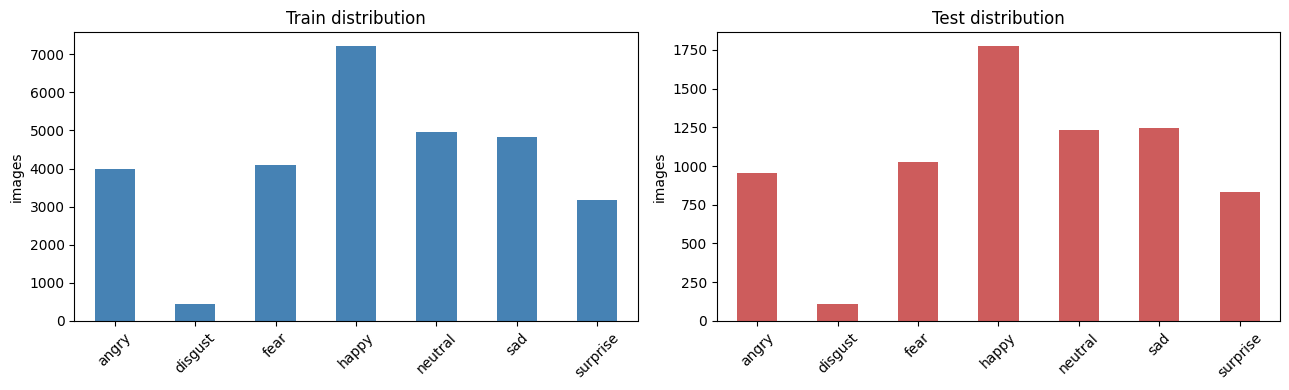

In [ ]:
probe_train = datasets.ImageFolder(train_dir)
probe_test  = datasets.ImageFolder(test_dir)
CLASS_NAMES = probe_train.classes
print('Emotions:', CLASS_NAMES)

c_tr = Counter(CLASS_NAMES[t] for t in probe_train.targets)
c_te = Counter(probe_test.classes[t] for t in probe_test.targets)
dist = pd.DataFrame({'train': c_tr, 'test': c_te}).reindex(CLASS_NAMES).fillna(0).astype(int)
dist['train_%'] = (100 * dist['train'] / dist['train'].sum()).round(1)
print(dist)

imb = dist['train'].max() / dist['train'].min()
print('\nTrain images: {:,} | Test images: {:,}'.format(dist['train'].sum(), dist['test'].sum()))
print('Imbalance ratio (max/min class) = {:.1f}x  ->  '.format(imb) +
      ('SIGNIFICANT, will use class weighting / sampler.' if imb > 3 else 'mild.'))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dist['train'].plot(kind='bar', ax=ax[0], color='steelblue'); ax[0].set_title('Train distribution')
dist['test'].plot(kind='bar', ax=ax[1], color='indianred'); ax[1].set_title('Test distribution')
for a in ax: a.set_ylabel('images'); a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

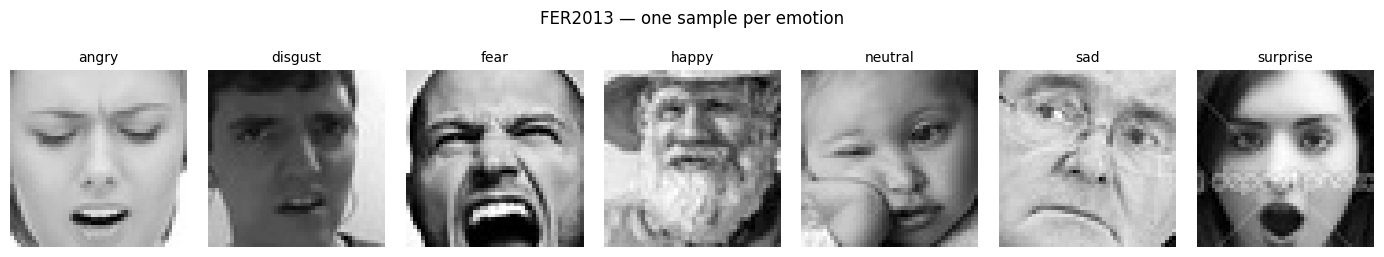

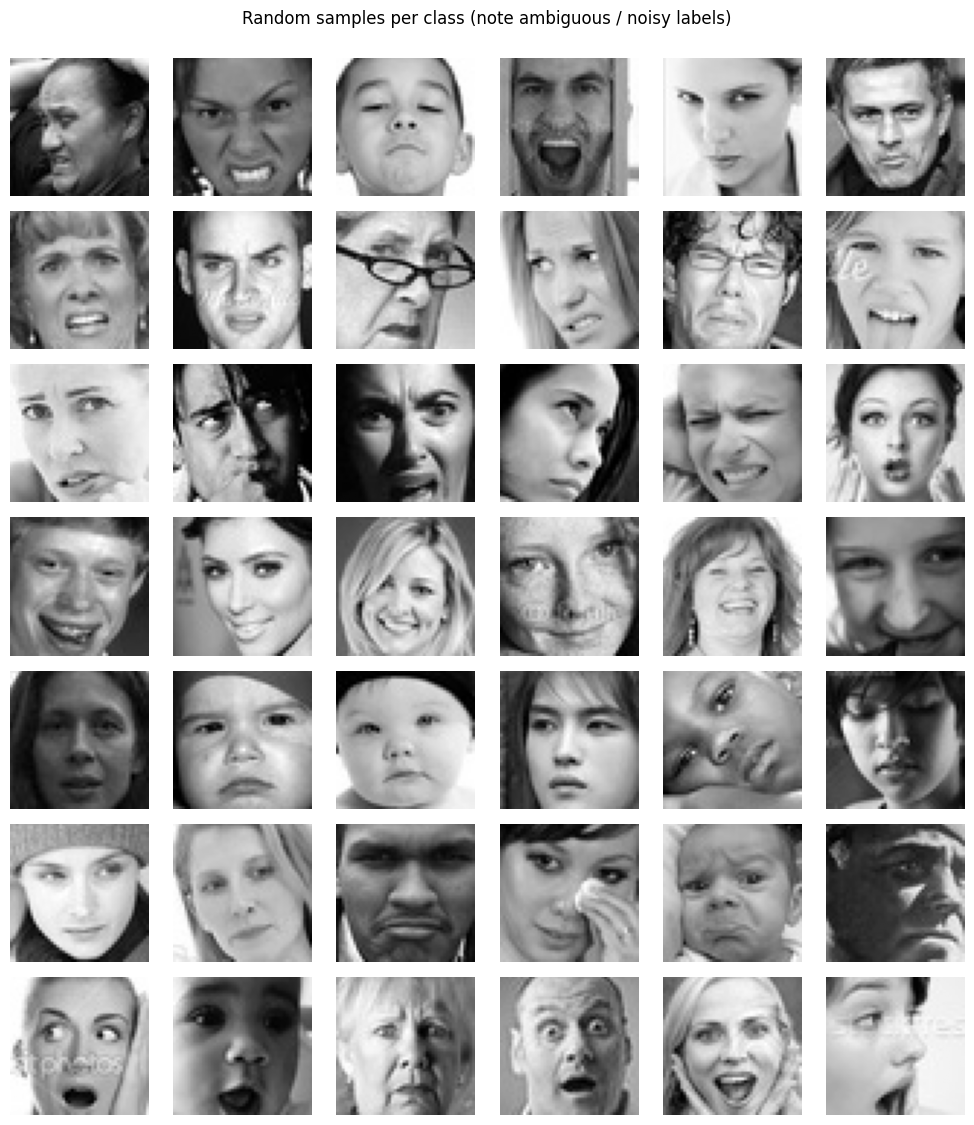

In [ ]:
# One representative sample per class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(2.0*len(CLASS_NAMES), 2.4))
for ax, cls in zip(axes, CLASS_NAMES):
    folder = os.path.join(train_dir, cls)
    img = Image.open(os.path.join(folder, os.listdir(folder)[0]))
    ax.imshow(img, cmap='gray'); ax.set_title(cls, fontsize=10); ax.axis('off')
plt.suptitle('FER2013 — one sample per emotion', y=1.05); plt.tight_layout(); plt.show()

# A grid of random faces to feel the label noise / ambiguity
fig, axes = plt.subplots(len(CLASS_NAMES), 6, figsize=(10, 1.6*len(CLASS_NAMES)))
for r, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(train_dir, cls)
    picks = random.sample(os.listdir(folder), 6)
    for c, fn in enumerate(picks):
        axes[r, c].imshow(Image.open(os.path.join(folder, fn)), cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(cls, rotation=0, ha='right', va='center', fontsize=10)
plt.suptitle('Random samples per class (note ambiguous / noisy labels)', y=1.0)
plt.tight_layout(); plt.show()

## 3 · Preprocessing & face-aware augmentation

Augmentations are chosen to **preserve expression semantics**:
- ✅ horizontal flip, small rotation (±12°), mild zoom/translate, brightness/contrast.
- ✅ `RandomErasing` (light) for occlusion robustness.
- ❌ **no vertical flip** and no large rotations — they destroy the facial geometry
  that defines an emotion.

Two transform pipelines:
- **CNN** path: 1-channel, native 48×48, normalized to `[-1, 1]`.
- **Transfer** path: grayscale→3 channels, upscaled to 96×96, ImageNet-normalized
  (so pretrained MobileNetV2 weights stay valid).

In [ ]:
# --- Custom CNN pipeline (1 channel, 48x48) ---
train_tf_cnn = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])
eval_tf_cnn = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# --- Transfer-learning pipeline (3 channels, 96x96, ImageNet stats) ---
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf_tl = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf_tl = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print('Transforms ready (CNN: 1x48x48 | TL: 3x96x96).')

Transforms ready (CNN: 1x48x48 | TL: 3x96x96).


In [ ]:
# Class metadata + loss weights (computed once, on the full train set)
num_classes = len(CLASS_NAMES)
_targets_all = np.array(probe_train.targets)
_counts = np.bincount(_targets_all, minlength=num_classes)
# inverse-frequency weights, normalized so the mean weight is ~1
class_weights_np = _counts.sum() / (num_classes * np.maximum(_counts, 1))
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
print('Per-class loss weights:')
for n, w in zip(CLASS_NAMES, class_weights_np):
    print('  {:10s} {:.3f}'.format(n, w))


def make_loaders(kind, batch_size=BATCH_SIZE, use_sampler=False, val_frac=0.1):
    '''Build (train, val, test) loaders. kind in {'cnn','tl'}.
    Train/val come from a stratified split of train_dir; test is test_dir.
    Two ImageFolder instances let train and val use different transforms.'''
    tt = train_tf_cnn if kind == 'cnn' else train_tf_tl
    et = eval_tf_cnn  if kind == 'cnn' else eval_tf_tl
    ds_train_aug  = datasets.ImageFolder(train_dir, transform=tt)
    ds_train_eval = datasets.ImageFolder(train_dir, transform=et)
    ds_test       = datasets.ImageFolder(test_dir,  transform=et)

    targets = np.array(ds_train_aug.targets)
    idx = np.arange(len(targets))
    tr_idx, val_idx = train_test_split(idx, test_size=val_frac,
                                       stratify=targets, random_state=SEED)
    train_ds = Subset(ds_train_aug,  tr_idx)
    val_ds   = Subset(ds_train_eval, val_idx)

    if use_sampler:
        tr_t = targets[tr_idx]
        per_class = 1.0 / np.maximum(np.bincount(tr_t, minlength=num_classes), 1)
        sample_w = per_class[tr_t]
        sampler = WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.float32),
                                        num_samples=len(sample_w), replacement=True)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                                  num_workers=2, pin_memory=True, drop_last=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                  num_workers=2, pin_memory=True, drop_last=True)
    val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

# Sanity check
_dbg = make_loaders('cnn', batch_size=64)[0]
_xb, _yb = next(iter(_dbg))
print('Sanity batch:', _xb.shape, '| range [{:.2f}, {:.2f}]'.format(_xb.min().item(), _xb.max().item()))

Per-class loss weights:
  angry      1.027
  disgust    9.407
  fear       1.001
  happy      0.568
  neutral    0.826
  sad        0.849
  surprise   1.293
Sanity batch: torch.Size([64, 1, 48, 48]) | range [-1.00, 1.00]


## 4 · Models

Two families:
1. **`EmotionCNN`** — a configurable VGG-style baseline (depth, width, dropout,
   batch-norm) so we can sweep capacity.
2. **MobileNetV2 transfer** — ImageNet-pretrained, grayscale-fed (3-ch repeat),
   classifier head swapped to 7 classes. (Swap to EfficientNet-B0 by replacing the
   builder — noted inline.)

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, drop):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(drop),
        )
    def forward(self, x): return self.net(x)


class EmotionCNN(nn.Module):
    '''Configurable VGG-style CNN for 48x48 grayscale FER.'''
    def __init__(self, num_classes=7, in_channels=1, dropout=0.4, width=64, depth=4):
        super().__init__()
        blocks, c_in, c_out = [], in_channels, width
        for _ in range(depth):
            blocks.append(ConvBlock(c_in, c_out, dropout * 0.5))
            c_in, c_out = c_out, min(c_out * 2, 512)
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c_in, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


def build_mobilenetv2(num_classes=7, pretrained=True, freeze_features=False):
    try:
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.mobilenet_v2(weights=weights)
    except Exception:
        m = models.mobilenet_v2(pretrained=pretrained)
    if freeze_features:
        for p in m.features.parameters():
            p.requires_grad = False
    in_f = m.classifier[-1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, num_classes))
    return m
    # To try EfficientNet-B0 instead:
    #   m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    #   m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)

# quick shape check
_m = EmotionCNN(num_classes=num_classes)
print('EmotionCNN params: {:.2f}M'.format(sum(p.numel() for p in _m.parameters())/1e6))
print('Forward 48x48 ->', _m(torch.randn(2, 1, 48, 48)).shape)
del _m

EmotionCNN params: 4.82M
Forward 48x48 -> torch.Size([2, 7])


## 5 · Training utilities

A single `fit()` loop with everything the task asks for:
- **Focal loss** *or* **class-weighted cross-entropy** (+ optional label smoothing).
- **Optimizers:** AdamW or SGD+momentum(Nesterov).
- **Schedulers:** cosine decay or `ReduceLROnPlateau`.
- **Callbacks:** early stopping + best-val-accuracy checkpointing.
- **Mixed precision (AMP)** for ~2× T4 speedup, with cross-version AMP shims.

In [ ]:
# AMP shims that work across torch versions
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(enabled): return _GradScaler('cuda', enabled=enabled)
    def amp_ctx(enabled):     return _autocast('cuda', enabled=enabled)
except Exception:
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(enabled): return _GradScaler(enabled=enabled)
    def amp_ctx(enabled):     return _autocast(enabled=enabled)


class FocalLoss(nn.Module):
    '''Multi-class focal loss; down-weights easy examples, helps minority classes.'''
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma = gamma; self.weight = weight
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum, total, preds, tgts = 0.0, 0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        out = model(xb)
        if criterion is not None:
            loss_sum += criterion(out, yb).item() * xb.size(0)
        preds.append(out.argmax(1).cpu()); tgts.append(yb.cpu()); total += xb.size(0)
    preds = torch.cat(preds).numpy(); tgts = torch.cat(tgts).numpy()
    return (loss_sum / total if criterion is not None else 0.0), (preds == tgts).mean(), preds, tgts


def fit(model, train_loader, val_loader, epochs, criterion, optimizer,
        scheduler=None, scheduler_type=None, patience=8, ckpt_path='best.pt', use_amp=True):
    model.to(device)
    use_amp = use_amp and device.type == 'cuda'
    scaler = make_scaler(use_amp)
    best_acc, best_state, wait = 0.0, None, 0
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train(); run_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with amp_ctx(use_amp):
                out = model(xb); loss = criterion(out, yb)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            run_loss += loss.item() * xb.size(0)
            correct  += (out.argmax(1) == yb).sum().item(); total += xb.size(0)
        tr_loss, tr_acc = run_loss / total, correct / total
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        lr_now = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            scheduler.step(val_acc) if scheduler_type == 'plateau' else scheduler.step()

        for k, v in zip(hist, [tr_loss, tr_acc, val_loss, val_acc, lr_now]):
            hist[k].append(v)
        print('Epoch {:02d}/{:02d} | lr {:.1e} | train loss {:.3f} acc {:.3f} | val loss {:.3f} acc {:.3f}'
              .format(ep, epochs, lr_now, tr_loss, tr_acc, val_loss, val_acc))

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, ckpt_path); wait = 0
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping at epoch {} (best val acc {:.3f}).'.format(ep, best_acc)); break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist, best_acc, time.time() - t0


def plot_history(hist, name):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['val_loss'], label='val')
    ax[0].set_title(name + ' — loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(hist['train_acc'], label='train'); ax[1].plot(hist['val_acc'], label='val')
    ax[1].set_title(name + ' — accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

print('Training utilities ready.')

Training utilities ready.


## 6 · Experiments

We benchmark **three configurations** that vary the axes the task cares about
(architecture, optimizer, schedule, imbalance strategy):

| Config | Model | Optimizer | Schedule | Imbalance |
|---|---|---|---|---|
| `cnn_baseline`   | custom CNN (w64,d4) | AdamW | cosine | weighted CE |
| `cnn_focal_sgd`  | custom CNN (w64,d4, more dropout) | SGD+Nesterov | ReduceLROnPlateau | **focal loss + weighted sampler** |
| `mobilenetv2_tl` | MobileNetV2 (pretrained) | AdamW | cosine | weighted CE |

> ⏱️ **T4 timing.** The two CNNs run ~12–18 s/epoch → ~8–12 min each at 40 epochs
> (early stopping usually ends sooner). **MobileNetV2 at 96×96 is heavier
> (~30–40 s/epoch)** and is capped at ~20 epochs (~10–13 min). If your budget is
> tight, set `QUICK_RUN = True` at the top, or run just `cnn_baseline`.

In [ ]:
EXPERIMENTS_RESULTS = []      # list of result dicts
TRAINED_MODELS = {}           # name -> trained model (in memory)

configs = [
    dict(name='cnn_baseline', kind='cnn', optimizer='adam', lr=1e-3,
         scheduler='cosine', loss='ce', class_weight=True, label_smoothing=0.05,
         dropout=0.4, width=64, depth=4, epochs=NUM_EPOCHS, batch_size=128, patience=8),

    dict(name='cnn_focal_sgd', kind='cnn', optimizer='sgd', lr=0.05, wd=5e-4,
         scheduler='plateau', loss='focal', class_weight=True, use_sampler=True,
         dropout=0.5, width=64, depth=4, epochs=NUM_EPOCHS, batch_size=128, patience=8),

    dict(name='mobilenetv2_tl', kind='tl', optimizer='adam', lr=7e-4,
         scheduler='cosine', loss='ce', class_weight=True, freeze_features=False,
         epochs=8 if QUICK_RUN else 20, batch_size=128, patience=6),
]


def run_experiment(cfg):
    print('=' * 64); print('RUN:', cfg['name']); print('=' * 64)
    train_loader, val_loader, test_loader = make_loaders(
        cfg['kind'], batch_size=cfg.get('batch_size', BATCH_SIZE),
        use_sampler=cfg.get('use_sampler', False))

    if cfg['kind'] == 'cnn':
        model = EmotionCNN(num_classes=num_classes, in_channels=1,
                           dropout=cfg.get('dropout', 0.4),
                           width=cfg.get('width', 64), depth=cfg.get('depth', 4))
    else:
        model = build_mobilenetv2(num_classes=num_classes, pretrained=True,
                                  freeze_features=cfg.get('freeze_features', False))

    weight = class_weights_t if cfg.get('class_weight', True) else None
    if cfg.get('loss', 'ce') == 'focal':
        criterion = FocalLoss(gamma=2.0, weight=weight)
    else:
        criterion = nn.CrossEntropyLoss(weight=weight,
                                        label_smoothing=cfg.get('label_smoothing', 0.0))

    if cfg['optimizer'] == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9,
                                    weight_decay=cfg.get('wd', 5e-4), nesterov=True)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'],
                                      weight_decay=cfg.get('wd', 1e-4))

    epochs = cfg.get('epochs', NUM_EPOCHS); sch = cfg.get('scheduler')
    if sch == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif sch == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    else:
        scheduler = None

    ckpt = '/content/ckpt_{}.pt'.format(cfg['name'])
    model, hist, best_val, secs = fit(model, train_loader, val_loader, epochs, criterion,
                                      optimizer, scheduler, sch,
                                      patience=cfg.get('patience', 8), ckpt_path=ckpt)

    _, test_acc, preds, tgts = evaluate(model, test_loader)
    result = dict(name=cfg['name'], kind=cfg['kind'], val_acc=best_val,
                  test_acc=float(test_acc), test_f1=float(f1_score(tgts, preds, average='macro')),
                  epochs_ran=len(hist['train_loss']), train_time_s=round(secs, 1),
                  params_M=round(sum(p.numel() for p in model.parameters())/1e6, 2),
                  ckpt=ckpt, cfg=cfg)
    plot_history(hist, cfg['name'])
    print('-> val_acc {:.4f} | test_acc {:.4f} | test_f1 {:.4f} | {:.1f}s'
          .format(best_val, test_acc, result['test_f1'], secs))
    return model, hist, result


def register(model, result):
    TRAINED_MODELS[result['name']] = model
    EXPERIMENTS_RESULTS[:] = [r for r in EXPERIMENTS_RESULTS if r['name'] != result['name']]
    EXPERIMENTS_RESULTS.append(result)

print('Configs defined. Run the next cells one at a time.')

Configs defined. Run the next cells one at a time.


RUN: cnn_baseline
Epoch 01/40 | lr 1.0e-03 | train loss 2.083 acc 0.103 | val loss 2.027 acc 0.077
Epoch 02/40 | lr 1.0e-03 | train loss 2.055 acc 0.109 | val loss 2.027 acc 0.054
Epoch 03/40 | lr 9.9e-04 | train loss 2.035 acc 0.119 | val loss 1.978 acc 0.188
Epoch 04/40 | lr 9.9e-04 | train loss 1.971 acc 0.180 | val loss 1.848 acc 0.254
Epoch 05/40 | lr 9.8e-04 | train loss 1.877 acc 0.269 | val loss 1.791 acc 0.369
Epoch 06/40 | lr 9.6e-04 | train loss 1.774 acc 0.355 | val loss 1.690 acc 0.412
Epoch 07/40 | lr 9.5e-04 | train loss 1.726 acc 0.387 | val loss 1.633 acc 0.446
Epoch 08/40 | lr 9.3e-04 | train loss 1.666 acc 0.421 | val loss 1.588 acc 0.444
Epoch 09/40 | lr 9.0e-04 | train loss 1.628 acc 0.441 | val loss 1.525 acc 0.503
Epoch 10/40 | lr 8.8e-04 | train loss 1.600 acc 0.460 | val loss 1.547 acc 0.528
Epoch 11/40 | lr 8.5e-04 | train loss 1.572 acc 0.472 | val loss 1.469 acc 0.553
Epoch 12/40 | lr 8.2e-04 | train loss 1.548 acc 0.485 | val loss 1.452 acc 0.545
Epoch 13/4

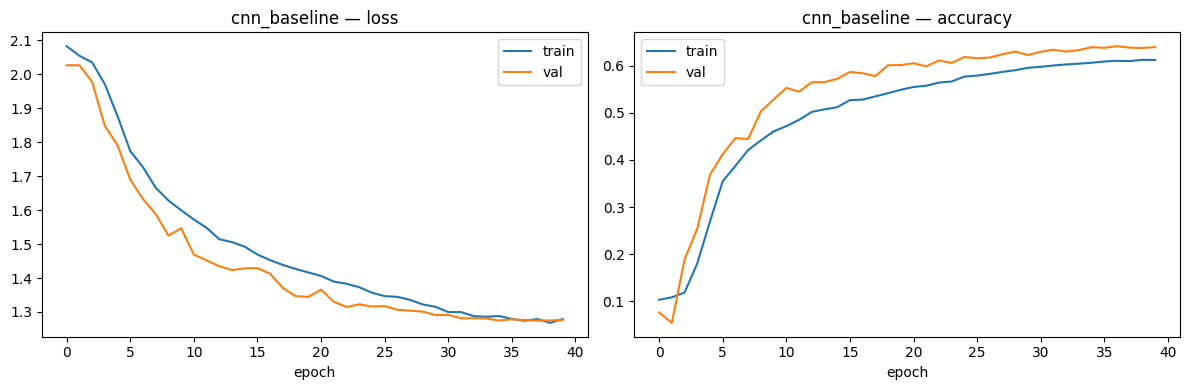

-> val_acc 0.6412 | test_acc 0.6349 | test_f1 0.5875 | 1329.5s


In [ ]:
# Experiment 1 — custom CNN baseline (AdamW + cosine + weighted CE)
m, h, r = run_experiment(configs[0]); register(m, r)

RUN: cnn_focal_sgd
Epoch 01/40 | lr 5.0e-02 | train loss 3.025 acc 0.146 | val loss 1.887 acc 0.015
Epoch 02/40 | lr 5.0e-02 | train loss 2.458 acc 0.144 | val loss 1.901 acc 0.015
Epoch 03/40 | lr 5.0e-02 | train loss 2.449 acc 0.146 | val loss 2.042 acc 0.015
Epoch 04/40 | lr 5.0e-02 | train loss 2.436 acc 0.145 | val loss 1.851 acc 0.015
Epoch 05/40 | lr 5.0e-02 | train loss 2.444 acc 0.145 | val loss 1.916 acc 0.016
Epoch 06/40 | lr 5.0e-02 | train loss 2.432 acc 0.142 | val loss 1.864 acc 0.015
Epoch 07/40 | lr 5.0e-02 | train loss 2.405 acc 0.142 | val loss 2.156 acc 0.015
Epoch 08/40 | lr 5.0e-02 | train loss 2.294 acc 0.149 | val loss 1.810 acc 0.034
Epoch 09/40 | lr 5.0e-02 | train loss 2.177 acc 0.175 | val loss 1.641 acc 0.086
Epoch 10/40 | lr 5.0e-02 | train loss 2.016 acc 0.208 | val loss 1.575 acc 0.082
Epoch 11/40 | lr 5.0e-02 | train loss 1.862 acc 0.241 | val loss 1.477 acc 0.123
Epoch 12/40 | lr 5.0e-02 | train loss 1.735 acc 0.260 | val loss 1.202 acc 0.205
Epoch 13/

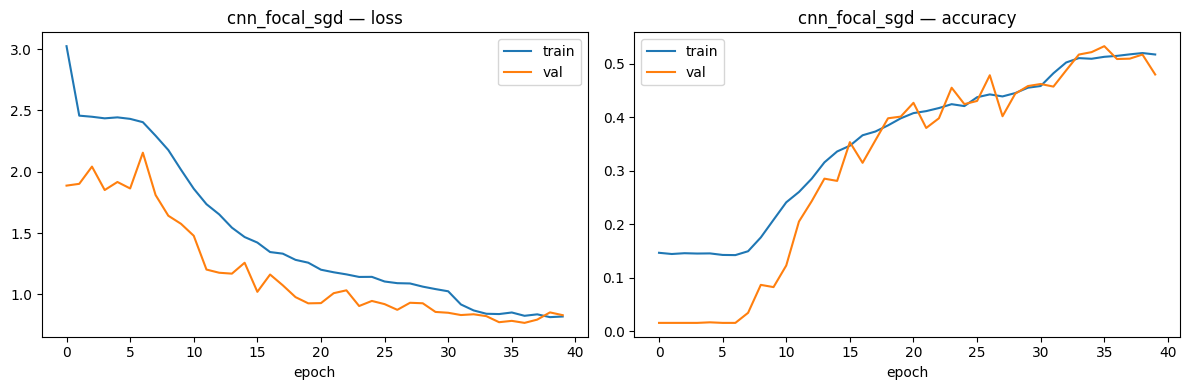

-> val_acc 0.5326 | test_acc 0.5320 | test_f1 0.4737 | 1276.5s


In [ ]:
# Experiment 2 — custom CNN with focal loss + SGD + plateau + weighted sampler
m, h, r = run_experiment(configs[1]); register(m, r)

RUN: mobilenetv2_tl
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]


Epoch 01/20 | lr 7.0e-04 | train loss 1.564 acc 0.403 | val loss 1.389 acc 0.453
Epoch 02/20 | lr 7.0e-04 | train loss 1.302 acc 0.506 | val loss 1.321 acc 0.514
Epoch 03/20 | lr 6.8e-04 | train loss 1.186 acc 0.548 | val loss 1.150 acc 0.584
Epoch 04/20 | lr 6.6e-04 | train loss 1.139 acc 0.567 | val loss 1.100 acc 0.589
Epoch 05/20 | lr 6.3e-04 | train loss 1.084 acc 0.584 | val loss 1.142 acc 0.621
Epoch 06/20 | lr 6.0e-04 | train loss 1.047 acc 0.599 | val loss 1.175 acc 0.610
Epoch 07/20 | lr 5.6e-04 | train loss 1.006 acc 0.613 | val loss 1.083 acc 0.612
Epoch 08/20 | lr 5.1e-04 | train loss 0.969 acc 0.624 | val loss 1.047 acc 0.628
Epoch 09/20 | lr 4.6e-04 | train loss 0.944 acc 0.631 | val loss 1.035 acc 0.623
Epoch 10/20 | lr 4.0e-04 | train loss 0.895 acc 0.648 | val loss 1.035 acc 0.643
Epoch 11/20 | lr 3.5e-04 | train loss 0.854 acc 0.656 | val loss 1.077 acc 0.646
Epoch 12/20 | lr 3.0e-04 | train loss 0.830 acc 0.668 | val loss 1.092 acc 0.658
Epoch 13/20 | lr 2.4e-04 | t

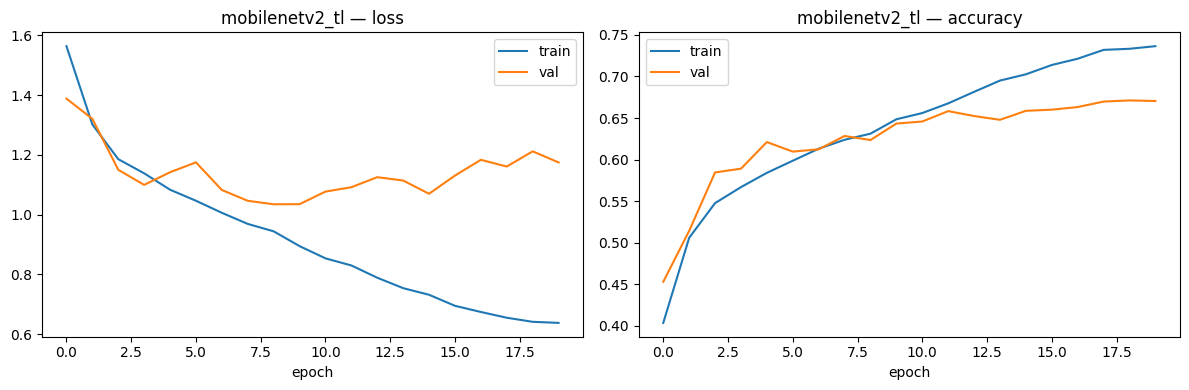

-> val_acc 0.6712 | test_acc 0.6715 | test_f1 0.6609 | 973.9s


In [ ]:
# Experiment 3 — MobileNetV2 transfer learning  (heaviest; see timing note above)
m, h, r = run_experiment(configs[2]); register(m, r)

## 7 · Evaluation (best model on the held-out test set)

We pick the config with the highest **validation** accuracy (no test-set peeking
for model selection) and report on the test set: confusion matrix, per-class
precision/recall/F1, and a misclassified-sample grid.

Best by val acc: mobilenetv2_tl (val 0.6712)
Test accuracy: 0.6715

              precision    recall  f1-score   support

       angry      0.575     0.619     0.596       958
     disgust      0.712     0.712     0.712       111
        fear      0.532     0.446     0.485      1024
       happy      0.896     0.843     0.868      1774
     neutral      0.576     0.738     0.647      1233
         sad      0.587     0.470     0.522      1247
    surprise      0.754     0.842     0.796       831

    accuracy                          0.671      7178
   macro avg      0.662     0.667     0.661      7178
weighted avg      0.673     0.671     0.668      7178



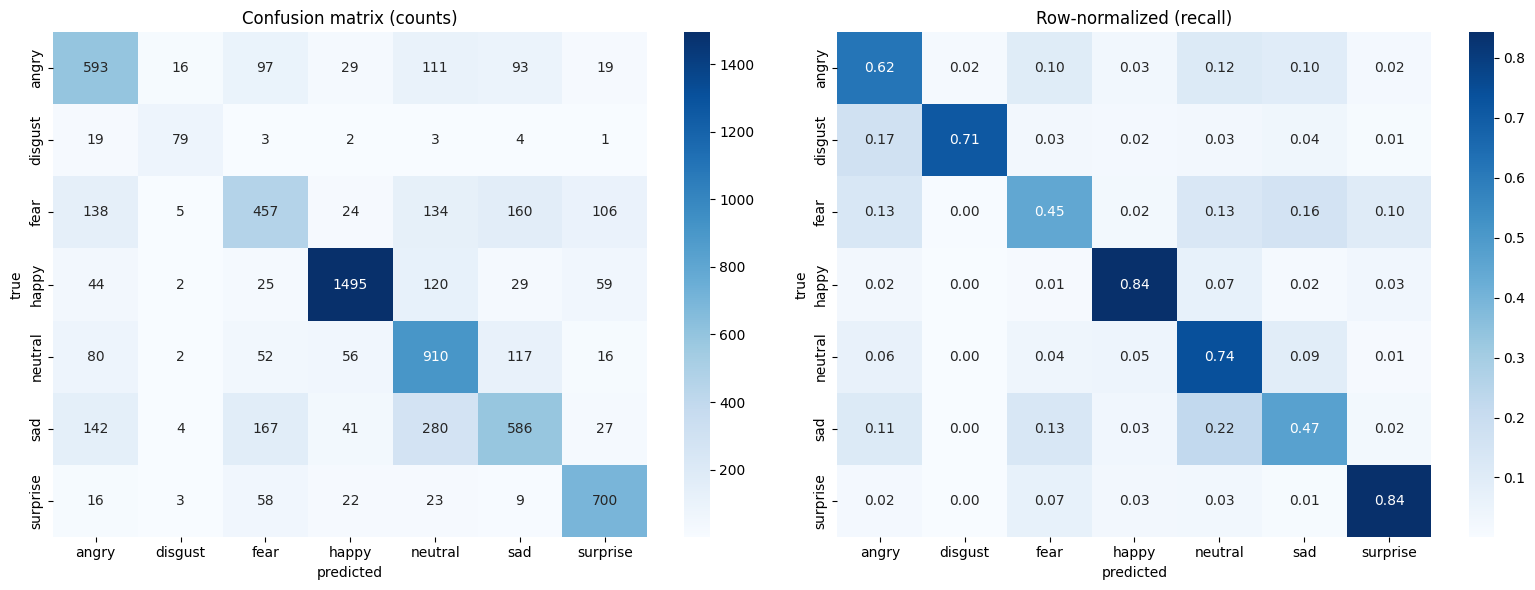

In [ ]:
assert EXPERIMENTS_RESULTS, 'Run at least one experiment cell first.'
best = max(EXPERIMENTS_RESULTS, key=lambda r: r['val_acc'])
best_model = TRAINED_MODELS[best['name']]
print('Best by val acc:', best['name'], '(val {:.4f})'.format(best['val_acc']))

_, _, test_loader = make_loaders(best['kind'])
_, test_acc, preds, tgts = evaluate(best_model, test_loader)
print('Test accuracy: {:.4f}\n'.format(test_acc))

print(classification_report(tgts, preds, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(tgts, preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax[0]); ax[0].set_title('Confusion matrix (counts)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax[1]); ax[1].set_title('Row-normalized (recall)')
for a in ax: a.set_xlabel('predicted'); a.set_ylabel('true')
plt.tight_layout(); plt.show()

2358 / 7178 test images misclassified.


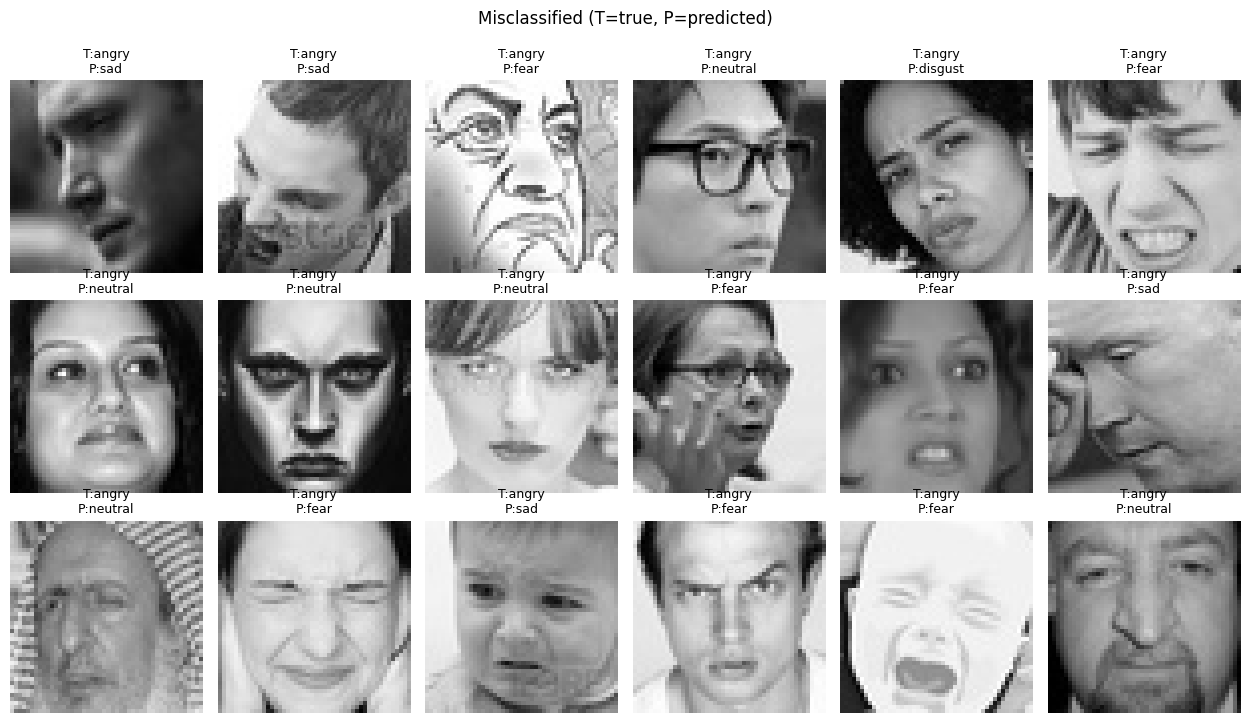

In [ ]:
# Misclassified samples — read originals from disk (loader order == ImageFolder order, shuffle=False)
disp = datasets.ImageFolder(test_dir)   # no transform -> raw PIL for display
mis = np.where(preds != tgts)[0]
print('{} / {} test images misclassified.'.format(len(mis), len(tgts)))

show = mis[:18]
cols = 6; rows = int(np.ceil(len(show) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.1*cols, 2.4*rows))
for ax, i in zip(np.array(axes).ravel(), show):
    img, _ = disp[i]
    ax.imshow(img, cmap='gray')
    ax.set_title('T:{}\nP:{}'.format(CLASS_NAMES[tgts[i]], CLASS_NAMES[preds[i]]), fontsize=9)
    ax.axis('off')
for ax in np.array(axes).ravel()[len(show):]:
    ax.axis('off')
plt.suptitle('Misclassified (T=true, P=predicted)', y=1.0); plt.tight_layout(); plt.show()

## 8 · Comparison summary

All configs side-by-side by validation accuracy, test accuracy, **macro-F1**
(the fair metric under imbalance), epochs actually run, wall-clock training time,
and parameter count.

In [ ]:
summary = pd.DataFrame(EXPERIMENTS_RESULTS)[
    ['name', 'kind', 'val_acc', 'test_acc', 'test_f1', 'epochs_ran', 'train_time_s', 'params_M']
].copy()
summary['train_time_min'] = (summary['train_time_s'] / 60).round(1)
summary = summary.drop(columns='train_time_s').sort_values('test_f1', ascending=False).reset_index(drop=True)
for c in ['val_acc', 'test_acc', 'test_f1']:
    summary[c] = summary[c].round(4)
print('FER2013 — configuration comparison\n')
print(summary.to_string(index=False))
try:
    from IPython.display import display
    display(summary.style.highlight_max(subset=['val_acc', 'test_acc', 'test_f1'], color='#b7e4c7'))
except Exception:
    pass

FER2013 — configuration comparison

          name kind  val_acc  test_acc  test_f1  epochs_ran  params_M  train_time_min
mobilenetv2_tl   tl   0.6712    0.6715   0.6609          20      2.23            16.2
  cnn_baseline  cnn   0.6412    0.6349   0.5875          40      4.82            22.2
 cnn_focal_sgd  cnn   0.5326    0.5320   0.4737          40      4.82            21.3


,name,kind,val_acc,test_acc,test_f1,epochs_ran,params_M,train_time_min
0,mobilenetv2_tl,tl,0.671200,0.671500,0.660900,20,2.230000,16.200000
1,cnn_baseline,cnn,0.641200,0.634900,0.587500,40,4.820000,22.200000
2,cnn_focal_sgd,cnn,0.532600,0.532000,0.473700,40,4.820000,21.300000


## 9 · Save the best model

Saves weights **+ metadata** (class names, kind, input size, full config) so
inference can rebuild the exact architecture. Set `SAVE_TO_DRIVE = True` to
persist to Google Drive (survives runtime resets); otherwise it stays in
`/content` (lost when the runtime recycles).

In [ ]:
SAVE_TO_DRIVE = False   # True -> mount Drive and save there

save_dir = '/content'
if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        save_dir = '/content/drive/MyDrive/FER_models'
        os.makedirs(save_dir, exist_ok=True)
    except Exception as e:
        print('Drive mount failed, saving locally instead:', e)

SAVE_PATH = os.path.join(save_dir, 'best_fer_model.pt')
checkpoint = {
    'state_dict': best_model.state_dict(),
    'class_names': CLASS_NAMES,
    'kind': best['kind'],
    'img_size': IMG_SIZE_CNN if best['kind'] == 'cnn' else IMG_SIZE_TL,
    'cfg': best['cfg'],
    'metrics': {k: best[k] for k in ('val_acc', 'test_acc', 'test_f1')},
}
torch.save(checkpoint, SAVE_PATH)
print('Saved best model ({}) to: {}'.format(best['name'], SAVE_PATH))

Saved best model (mobilenetv2_tl) to: /content/best_fer_model.pt


## 10 · Inference A — upload a single image

Upload any photo. The cell does grayscale → (optional Haar) face crop →
preprocess → predict, then shows the image with the top emotion + confidence and
a full probability bar chart.

In [ ]:
import cv2

ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
INFER_KIND  = ckpt['kind']
INFER_SIZE  = ckpt['img_size']
INFER_NAMES = ckpt['class_names']

def build_model_from_cfg(cfg):
    if cfg['kind'] == 'cnn':
        return EmotionCNN(num_classes=len(INFER_NAMES), in_channels=1,
                          dropout=cfg.get('dropout', 0.4),
                          width=cfg.get('width', 64), depth=cfg.get('depth', 4))
    return build_mobilenetv2(num_classes=len(INFER_NAMES), pretrained=False)

infer_model = build_model_from_cfg(ckpt['cfg'])
infer_model.load_state_dict(ckpt['state_dict'])
infer_model.to(device).eval()

_infer_tf = eval_tf_cnn if INFER_KIND == 'cnn' else eval_tf_tl
_haar = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def crop_face(pil_img):
    '''Return the largest detected face as a PIL image, or the original if none.'''
    gray = cv2.cvtColor(np.array(pil_img.convert('RGB')), cv2.COLOR_RGB2GRAY)
    faces = _haar.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    if len(faces) == 0:
        return pil_img
    x, y, w, h = sorted(faces, key=lambda b: b[2]*b[3])[-1]
    return pil_img.crop((x, y, x + w, y + h))

@torch.no_grad()
def predict_emotion(pil_img, use_face_crop=True):
    face = crop_face(pil_img) if use_face_crop else pil_img
    x = _infer_tf(face).unsqueeze(0).to(device)
    probs = F.softmax(infer_model(x), dim=1)[0].cpu().numpy()
    top = int(probs.argmax())
    return INFER_NAMES[top], float(probs[top]), probs, face

print('Inference model ready:', INFER_KIND)

Inference model ready: tl


Saving PrivateTest_7622844.jpg to PrivateTest_7622844.jpg


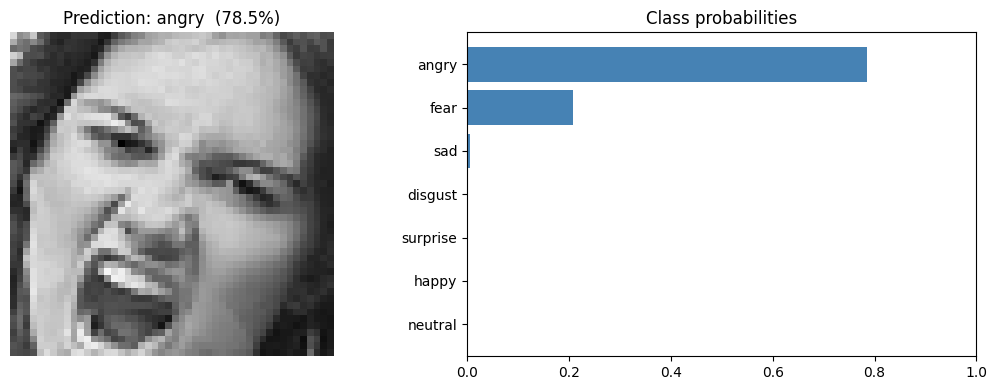

In [ ]:
from google.colab import files
up = files.upload()   # choose an image
fname = list(up.keys())[0]
img = Image.open(fname).convert('RGB')

label, conf, probs, face = predict_emotion(img, use_face_crop=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(face); ax[0].axis('off')
ax[0].set_title('Prediction: {}  ({:.1f}%)'.format(label, 100*conf), fontsize=12)
order = np.argsort(probs)
ax[1].barh([INFER_NAMES[i] for i in order], probs[order], color='steelblue')
ax[1].set_xlim(0, 1); ax[1].set_title('Class probabilities')
plt.tight_layout(); plt.show()

## 11 · Inference B — webcam capture (Colab)

`cv2.VideoCapture` cannot reach your camera from Colab, so we use the standard
**JavaScript `getUserMedia` snippet** to grab a frame, then run Haar face
detection + classification on it and draw boxes with labels.

Click **Capture** when the video preview appears. (Allow camera access.)

In [2]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='webcam.jpg', quality=0.9):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          capture.style.margin = '8px';
          div.appendChild(capture);
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
          await new Promise((resolve) => capture.onclick = resolve);
          // Add a small delay to ensure a frame is rendered
          await new Promise(r => setTimeout(r, 100));
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks().forEach(t => t.stop());
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

In [4]:

photo = take_photo()
print('Captured:', photo)

# Detect every face in the webcam frame, classify, and annotate.
frame = cv2.imread(photo)                       # BGR
gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = _haar.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
annotated = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

if len(faces) == 0:
    print('No face detected — classifying the whole frame.')
    label, conf, _, _ = predict_emotion(Image.fromarray(annotated), use_face_crop=False)
    print('Prediction: {} ({:.1f}%)'.format(label, 100*conf))
else:
    for (x, y, w, h) in faces:
        face_pil = Image.fromarray(annotated[y:y+h, x:x+w])
        label, conf, _, _ = predict_emotion(face_pil, use_face_crop=False)
        cv2.rectangle(annotated, (x, y), (x+w, y+h), (46, 204, 113), 2)
        cv2.putText(annotated, '{} {:.0f}%'.format(label, 100*conf), (x, max(0, y-8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (46, 204, 113), 2)

plt.figure(figsize=(7, 7)); plt.imshow(annotated); plt.axis('off')
plt.title('Webcam emotion detection'); plt.show()

<IPython.core.display.Javascript object>

Captured: webcam.jpg


NameError: name 'cv2' is not defined

## 12 · Where to go next

- **Biggest accuracy lever:** swap in **FER+** labels (same images) or move to
  **RAF-DB** — both beat tuning the model on noisy FER2013 labels.
- **Ensembling** the three trained models (average softmax) typically adds 1–2 pts.
- **Test-time augmentation** (predict on image + horizontal flip, average) is a
  free ~0.5–1 pt.
- For deployment, export the chosen `best_fer_model.pt` to the companion
  PyTorch/FastAPI/Docker project (architecture is reconstructable from the saved
  `cfg`).